# Netflix Content Trends Analysis

## Project Overview

This project analyzes Netflix Movies and TV Shows data using Python, Pandas, and Matplotlib.

The objective is to identify content trends, understand Netflix's content distribution, and derive insights related to content type, country of origin, growth over time, genre popularity, and audience ratings.

## Dataset

Source: Netflix Movies and TV Shows Dataset

Records: 8,807 titles

Features analyzed:
- Type
- Country
- Release Year
- Date Added
- Genre
- Rating

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'netflix_titles.csv'

In [5]:
import zipfile

with zipfile.ZipFile('netflix_titles.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [6]:
import os

os.listdir()

['.config', 'netflix_titles.csv.zip', 'netflix_titles.csv', 'sample_data']

In [7]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.shape

(8807, 12)

In [9]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [13]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

In [14]:
df = df.dropna(subset=['date_added','duration'])


In [15]:
df['type'].value_counts()

,count
type,
Movie,6128
TV Show,2666


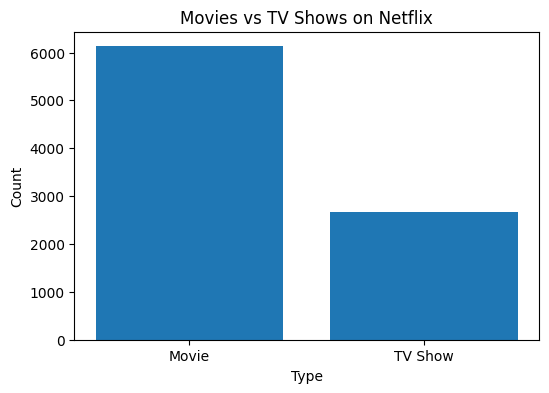

In [16]:
import matplotlib.pyplot as plt

type_count = df['type'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(type_count.index, type_count.values)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [30]:
plt.savefig("movies_vs_tv.png")

<Figure size 640x480 with 0 Axes>

## Insight 1: Movies vs TV Shows

Netflix's catalog is dominated by Movies, which significantly outnumber TV Shows. This suggests that Netflix has historically focused more on movie content than episodic television content.

In [17]:
df['type'].value_counts()

,count
type,
Movie,6128
TV Show,2666


In [18]:
df['country'].value_counts().head(10)

,count
country,
United States,2809
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


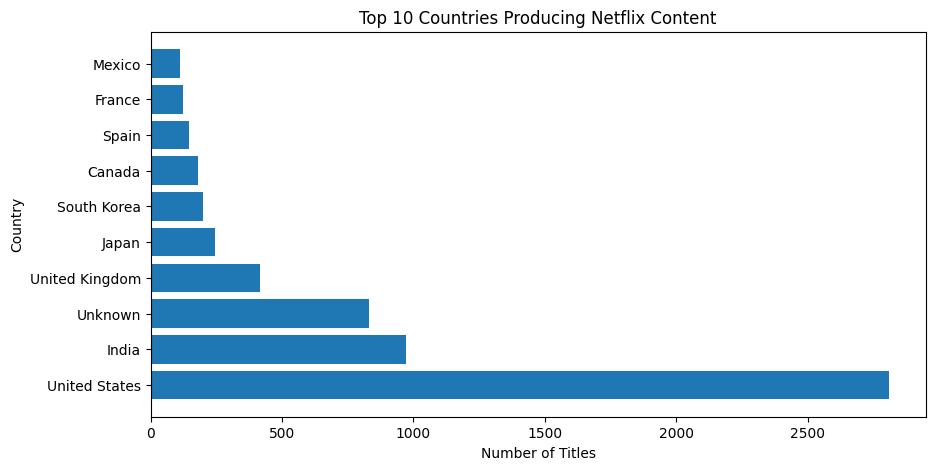

In [19]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(top_countries.index, top_countries.values)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

In [31]:
plt.savefig("top_countries.png")

<Figure size 640x480 with 0 Axes>

## Insight 2: Top Content-Producing Countries

The United States contributes the highest number of Netflix titles by a significant margin, demonstrating its dominant role in Netflix's content library.

India ranks second, highlighting Netflix's strong investment in the Indian entertainment market.

A notable number of titles have missing country information, represented as "Unknown", indicating incomplete metadata in the dataset.

In [22]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [23]:
df['year_added'] = df['date_added'].dt.year

In [24]:
year_count = df['year_added'].value_counts().sort_index()

year_count

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,416


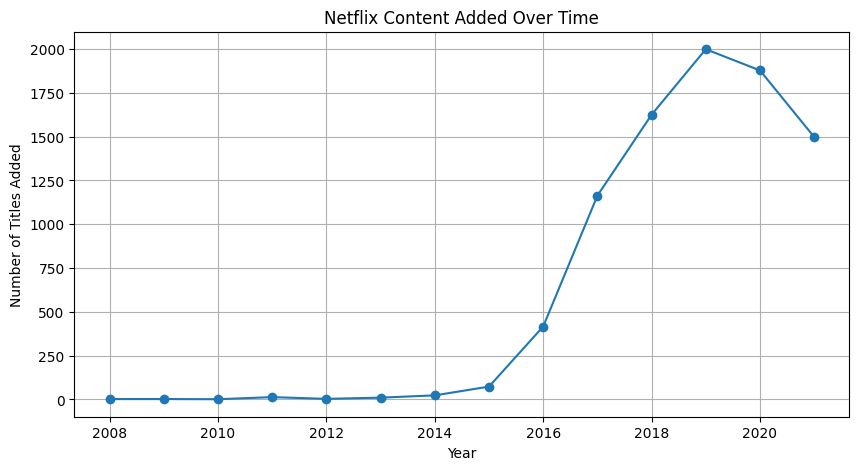

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    year_count.index,
    year_count.values,
    marker='o'
)

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid(True)

plt.show()


In [32]:
plt.savefig("content_over_time.png")

<Figure size 640x480 with 0 Axes>

## Insight 3: Netflix Content Growth Over Time

Netflix experienced rapid growth in content additions between 2016 and 2019, indicating an aggressive expansion of its content library during this period.

The platform reached its peak in 2019, when the highest number of titles were added. After 2019, content additions declined slightly, but Netflix continued to maintain a large volume of new content.

This trend reflects Netflix's strategy of rapidly expanding its catalog to attract and retain subscribers worldwide.

In [26]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1350
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


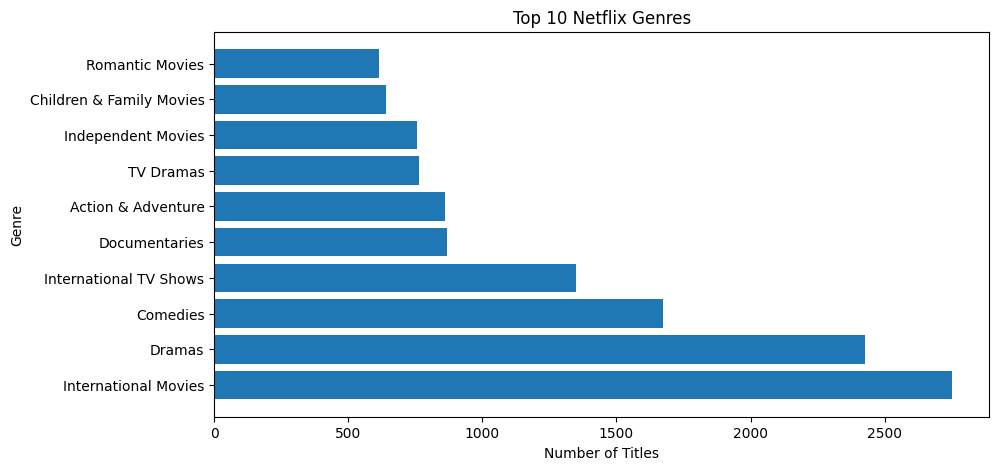

In [27]:
plt.figure(figsize=(10,5))

plt.barh(top_genres.index,
         top_genres.values)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [33]:
plt.savefig("top_genres.png")

<Figure size 640x480 with 0 Axes>

## Insight 4: Most Popular Netflix Genres

International Movies represent the largest genre category on Netflix, followed by Dramas and Comedies.

The prominence of International Movies and International TV Shows suggests that Netflix has expanded beyond its traditional North American audience and invested heavily in global content.

The strong presence of Dramas and Comedies indicates that these genres remain consistently popular among viewers worldwide.

In [28]:
rating_count = df['rating'].value_counts().head(10)

rating_count

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


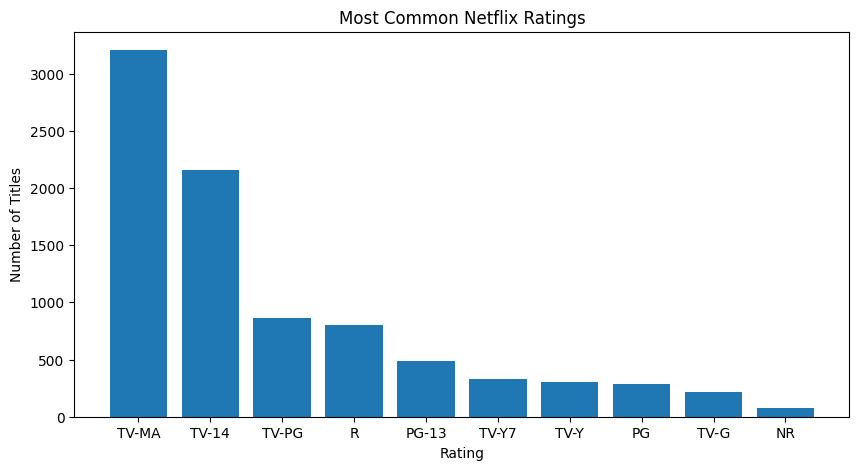

In [29]:
plt.figure(figsize=(10,5))

plt.bar(rating_count.index,
        rating_count.values)

plt.title("Most Common Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.show()

In [34]:
plt.savefig("netflix_ratings.png")

<Figure size 640x480 with 0 Axes>

## Insight 5: Content Ratings Distribution

TV-MA is the most common rating on Netflix by a significant margin, followed by TV-14.

This indicates that Netflix's content library is primarily targeted toward mature audiences and teenagers rather than young children.

While family-friendly categories such as TV-Y, TV-G, and TV-Y7 are present, they make up a much smaller portion of the catalog. This suggests that Netflix focuses heavily on content designed for older viewers, including dramas, thrillers, documentaries, and mature-themed entertainment.

Netflix appears to prioritize content for adults and teenagers, likely because these audience segments represent a large portion of its global subscriber base and viewing activity.

# Conclusion

The analysis reveals several important trends in Netflix's content strategy.

- Movies account for the majority of Netflix's catalog.
- The United States is the largest contributor of content, followed by India.
- Netflix experienced rapid content growth between 2016 and 2019.
- International Movies and Dramas are among the most popular genres.
- Most content is targeted toward adult and teenage audiences, as reflected by the dominance of TV-MA and TV-14 ratings.

Overall, Netflix has evolved into a global content platform with a strong focus on international and mature-audience entertainment.